<a href="https://colab.research.google.com/github/husseinlopez/IAdesdeCero2026/blob/main/8.2%20-%20Clasificacion_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Flujo de Orange en Python

Este notebook reproduce de forma simple el flujo mostrado en Orange:

1. Cargar un archivo CSV.
2. Crear un corpus de texto.
3. Preprocesar el texto.
4. Obtener dos representaciones:
   - Bolsa de palabras / TF-IDF.
   - Embeddings de documentos.
5. Entrenar varios modelos:
   - Red neuronal.
   - SVM.
   - kNN.
   - Random Forest.
6. Evaluar con validación cruzada.
7. Mostrar matrices de confusión.
8. Visualizar palabras frecuentes.

## 1. Librerías

Usaremos `pandas`, `scikit-learn`, `matplotlib` y `wordcloud`.

In [15]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Opcional para nube de palabras
try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None
    print("Si quieres usar WordCloud, instala: pip install wordcloud")

## 2. Cargar datos

Cambia `archivo.csv`, `TEXT_COL` y `LABEL_COL` según tu archivo.

- `TEXT_COL`: columna donde está el texto.
- `LABEL_COL`: columna con la clase o etiqueta.

In [4]:
CSV_PATH = "book_data.csv"      # Cambia esto
TEXT_COL = "summary"             # Cambia esto
LABEL_COL = "genre"           # Cambia esto

df = pd.read_csv(CSV_PATH)

df = df[[TEXT_COL, LABEL_COL]].dropna()
df.head()

,summary,genre
0,Drowned Wednesday is the first Trustee among ...,fantasy
1,"As the book opens, Jason awakens on a school ...",fantasy
2,Cugel is easily persuaded by the merchant Fia...,fantasy
3,The book opens with Herald-Mage Vanyel return...,fantasy
4,Taran and Gurgi have returned to Caer Dallben...,fantasy


## 3. Preprocesamiento de texto

Esto corresponde al widget **Preprocess Text** de Orange.

Aquí:
- Convertimos a minúsculas.
- Eliminamos signos de puntuación.
- Quitamos espacios repetidos.

In [5]:
def clean_text(text):
    text = str(text).lower()

    # Elimina signos de puntuación y símbolos, conserva letras, números y espacios
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)

    # Elimina espacios repetidos
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)

df[[TEXT_COL, "clean_text", LABEL_COL]].head()

,summary,clean_text,genre
0,Drowned Wednesday is the first Trustee among ...,drowned wednesday is the first trustee among t...,fantasy
1,"As the book opens, Jason awakens on a school ...",as the book opens jason awakens on a school bu...,fantasy
2,Cugel is easily persuaded by the merchant Fia...,cugel is easily persuaded by the merchant fian...,fantasy
3,The book opens with Herald-Mage Vanyel return...,the book opens with herald mage vanyel returni...,fantasy
4,Taran and Gurgi have returned to Caer Dallben...,taran and gurgi have returned to caer dallben ...,fantasy


## 4. Preparar etiquetas

Convertimos las clases de texto a números para que los modelos puedan entrenarse.

In [7]:
le = LabelEncoder()

X_text = df["clean_text"].values
y = le.fit_transform(df[LABEL_COL])

print("Clases:", list(le.classes_))
print("Número de documentos:", len(X_text))

Clases: ['crime', 'fantasy', 'history', 'horror', 'psychology', 'romance', 'science', 'sports', 'thriller', 'travel']
Número de documentos: 4657


## 5. Bolsa de palabras / TF-IDF

Esto corresponde al widget **Bag of Words** de Orange.

Usaremos `TfidfVectorizer`, que representa cada documento como un vector de palabras ponderadas por TF-IDF.

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2
)

X_tfidf = tfidf.fit_transform(X_text)

print("Forma de la matriz TF-IDF:", X_tfidf.shape)

Forma de la matriz TF-IDF: (4657, 5000)


## 6. Word Cloud

Esto corresponde al widget **Word Cloud**.

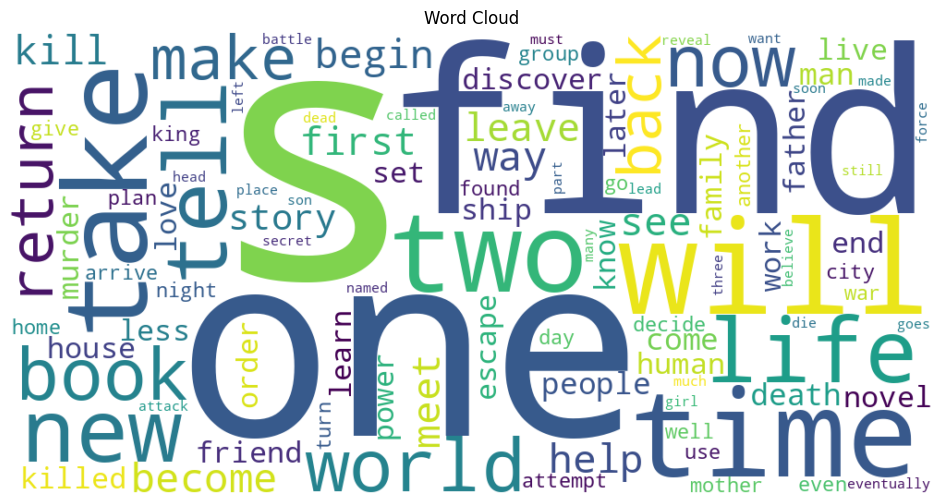

In [9]:
all_text = " ".join(df["clean_text"].values)

if WordCloud is not None:
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(all_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud")
    plt.show()
else:
    print("WordCloud no está instalado.")

## 7. Modelos a evaluar

Esto corresponde a los widgets:

- **Neural Network**
- **SVM**
- **kNN**
- **Random Forest**
- **Test and Score**
- **Confusion Matrix**

Usaremos validación cruzada estratificada.

In [17]:
models = {
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(256,256),
        max_iter=500,
        random_state=42
    ),
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ),
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 8. Evaluación con TF-IDF

Evaluamos todos los modelos usando la representación de bolsa de palabras / TF-IDF.

In [18]:
results = []

for name, model in models.items():
    start_time = time.perf_counter()
    scores = cross_validate(
        model,
        X_tfidf,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    results.append({
        "Modelo": name,
        "Accuracy promedio": scores["test_accuracy"].mean(),
        "F1 macro promedio": scores["test_f1_macro"].mean(),
        "F1 macro std": scores["test_f1_macro"].std(),
        "Tiempo (s)": elapsed_time,
        "Tiempo (min)": elapsed_time / 60
    })

results_df = pd.DataFrame(results).sort_values("F1 macro promedio", ascending=False)
results_df

,Modelo,Accuracy promedio,F1 macro promedio,F1 macro std,Tiempo (s),Tiempo (min)
0,Neural Network,0.666947,0.640275,0.027118,207.428702,3.457145
1,SVM,0.633669,0.503384,0.016620,139.337709,2.322295
3,Random Forest,0.601463,0.459968,0.021352,162.013042,2.700217
2,kNN,0.337113,0.226596,0.070060,1.381334,0.023022


## 9. Matriz de confusión del mejor modelo

Seleccionamos el modelo con mejor F1 macro y generamos predicciones con validación cruzada.

Mejor modelo: Neural Network

              precision    recall  f1-score   support

       crime       0.71      0.65      0.68       500
     fantasy       0.75      0.70      0.73       876
     history       0.69      0.72      0.71       600
      horror       0.58      0.59      0.59       600
  psychology       0.73      0.63      0.68       100
     romance       0.36      0.28      0.31       111
     science       0.71      0.68      0.70       647
      sports       0.90      0.62      0.73       100
    thriller       0.60      0.71      0.65      1023
      travel       0.88      0.52      0.65       100

    accuracy                           0.67      4657
   macro avg       0.69      0.61      0.64      4657
weighted avg       0.67      0.67      0.67      4657



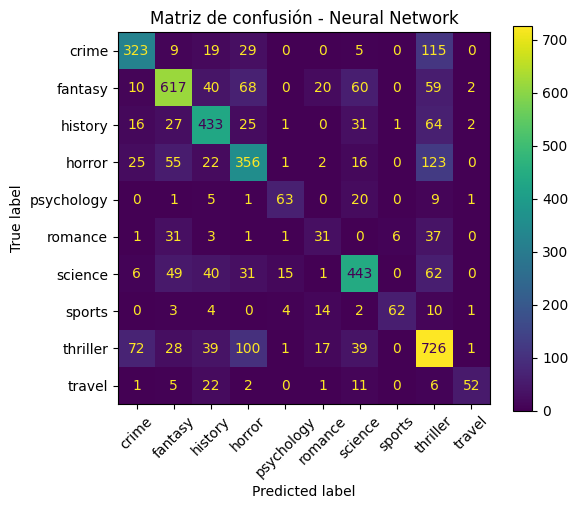

In [19]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

y_pred = cross_val_predict(
    best_model,
    X_tfidf,
    y,
    cv=cv,
    n_jobs=-1
)

print("Mejor modelo:", best_model_name)
print()
print(classification_report(y, y_pred, target_names=le.classes_))

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d", xticks_rotation=45)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

# Flujo alternativo: Document Embedding

En Orange, el widget **Document Embedding** convierte cada documento en un vector denso.

Aquí usaremos `sentence-transformers`.  
Primero instala, si es necesario:

```bash
pip install sentence-transformers
```

Este paso puede tardar más que TF-IDF.

In [20]:
USE_EMBEDDINGS = True

if USE_EMBEDDINGS:
    from sentence_transformers import SentenceTransformer

    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

    X_emb = embedding_model.encode(
        list(X_text),
        show_progress_bar=True,
        convert_to_numpy=True
    )

    print("Forma de embeddings:", X_emb.shape)
else:
    print("Activa USE_EMBEDDINGS = True para calcular embeddings.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/146 [00:00<?, ?it/s]

Forma de embeddings: (4657, 384)


## 10. Evaluación con Document Embedding

Los embeddings son vectores numéricos densos, por eso agregamos `StandardScaler` para SVM, kNN y red neuronal.

In [23]:
if USE_EMBEDDINGS:
    embedding_models = {
        "Neural Network": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(hidden_layer_sizes=(256,256), max_iter=500, random_state=42))
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="linear", C=1.0, gamma="scale", random_state=42))
        ]),
        "kNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5))
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    }

    emb_results = []

    for name, model in embedding_models.items():
        start_time = time.perf_counter()
        scores = cross_validate(
            model,
            X_emb,
            y,
            cv=cv,
            scoring=["accuracy", "f1_macro"],
            n_jobs=-1
        )

        end_time = time.perf_counter()
        elapsed_time = end_time - start_time

        emb_results.append({
            "Modelo": name,
            "Accuracy promedio": scores["test_accuracy"].mean(),
            "F1 macro promedio": scores["test_f1_macro"].mean(),
            "F1 macro std": scores["test_f1_macro"].std(),
            "Tiempo (s)": elapsed_time,
            "Tiempo (min)": elapsed_time / 60
        })

    emb_results_df = pd.DataFrame(emb_results).sort_values("F1 macro promedio", ascending=False)
    display(emb_results_df)
else:
    print("No se calcularon embeddings.")

,Modelo,Accuracy promedio,F1 macro promedio,F1 macro std,Tiempo (s),Tiempo (min)
0,Neural Network,0.587290,0.590792,0.015085,42.287615,0.704794
1,SVM,0.534467,0.553497,0.031617,59.088670,0.984811
2,kNN,0.546279,0.547400,0.021799,0.957126,0.015952
3,Random Forest,0.514712,0.367478,0.012279,102.748066,1.712468


## 11. Matriz de confusión con embeddings

Este bloque se ejecuta solo si `USE_EMBEDDINGS = True`.

Mejor modelo con embeddings: Neural Network

              precision    recall  f1-score   support

       crime       0.54      0.53      0.53       500
     fantasy       0.63      0.67      0.65       876
     history       0.59      0.68      0.63       600
      horror       0.50      0.49      0.49       600
  psychology       0.70      0.68      0.69       100
     romance       0.28      0.23      0.26       111
     science       0.65      0.58      0.61       647
      sports       0.83      0.75      0.79       100
    thriller       0.57      0.56      0.56      1023
      travel       0.76      0.66      0.71       100

    accuracy                           0.59      4657
   macro avg       0.60      0.58      0.59      4657
weighted avg       0.59      0.59      0.59      4657



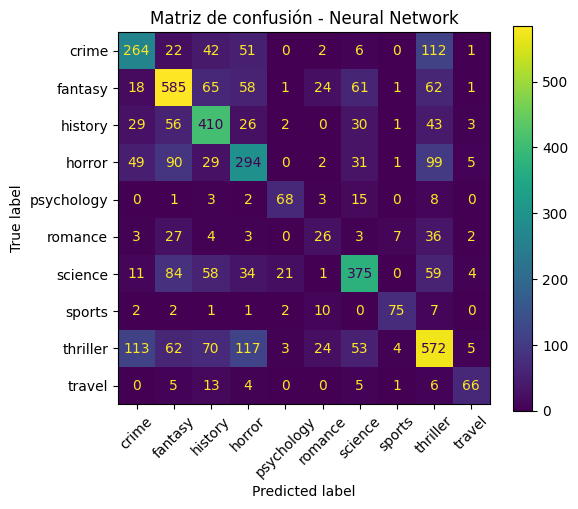

In [24]:
if USE_EMBEDDINGS:
    best_emb_model_name = emb_results_df.iloc[0]["Modelo"]
    best_emb_model = embedding_models[best_emb_model_name]

    y_pred_emb = cross_val_predict(
        best_emb_model,
        X_emb,
        y,
        cv=cv,
        n_jobs=-1
    )

    print("Mejor modelo con embeddings:", best_emb_model_name)
    print()
    print(classification_report(y, y_pred_emb, target_names=le.classes_))

    cm = confusion_matrix(y, y_pred_emb)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d", xticks_rotation=45)
    plt.title(f"Matriz de confusión - {best_emb_model_name}")
    plt.show()
else:
    print("No se calcularon embeddings.")

# Resumen

Este notebook reproduce el flujo de Orange de forma simple:

- `CSV File Import` → `pd.read_csv`
- `Corpus` → columna de texto en `pandas`
- `Preprocess Text` → función `clean_text`
- `Bag of Words` → `TfidfVectorizer`
- `Document Embedding` → `SentenceTransformer`
- `Neural Network`, `SVM`, `kNN`, `Random Forest` → modelos de `scikit-learn`
- `Test and Score` → `cross_validate`
- `Confusion Matrix` → `ConfusionMatrixDisplay`
- `Word Cloud` → `WordCloud`